# BrushCue Example: Radial Gradient

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/radial_gradient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/radial-gradient

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


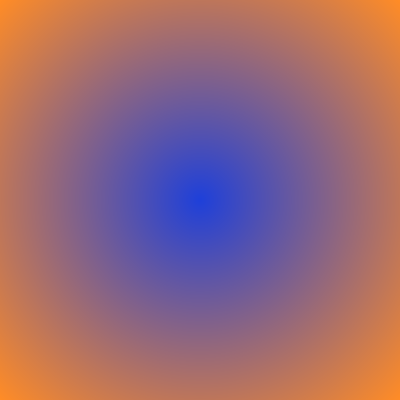

In [1]:
import io
from PIL import Image

import brushcue as bc

width = 1024
width_f = bc.Int.to_float(width)
height = 1024
height_f = bc.Int.to_float(height)
center_x = 0.5
center_y = 0.5
start_color = bc.ProfiledColor.from_srgb_hex("#1F40D9")
end_color = bc.ProfiledColor.from_srgb_hex("#FF8C26")
graph = bc.Composition.freeform_shader(
    "let size = vec2<f32>(width_f, height_f);\nlet c = vec2<f32>(center_x * size.x, center_y * size.y);\nlet m1 = distance(vec2<f32>(0.0, 0.0), c);\nlet m2 = distance(vec2<f32>(size.x, 0.0), c);\nlet m3 = distance(vec2<f32>(0.0, size.y), c);\nlet m4 = distance(vec2<f32>(size.x, size.y), c);\nlet maxd = max(max(m1, m2), max(m3, m4));\nlet t = clamp(distance(canvas_position, c) / max(maxd, 0.00001), 0.0, 1.0);\nreturn mix(start_color, end_color, t);",
    "",
    bc.Bounds2f.from_x_y_width_height(0.0, 0.0, width_f, height_f),
    bc.ColorRepresentation.srgb(),
    bc.Dictionary.create()
    .add("width_f", width_f)
    .add("height_f", height_f)
    .add("center_x", center_x)
    .add("center_y", center_y)
    .add("start_color", start_color)
    .add("end_color", end_color),
)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
